# Relationship between pedestrian accidents and road/weather conditions

In this paper was examined **how road surface conditions influence the incidence of pedestrian accidents**. The relationship between weather conditions and pedestrian accidents was also examined.

To assess the relationship between pedestrian accidents and environmental factors, a contingency table analysis was conducted using Python's SciPy library. Pedestrian-involved accidents (n=617) were identified using both accident type (Kokkupõrge jalakäijaga) and pedestrian involvement flag (pedestrian = 1). The association strength was measured using Odds Ratio (OR) and Cramér's V, while statistical significance was tested with the Chi-square test (α = 0.05). Road condition was classified as "bad" when surface status indicated snow, ice, mud, or wetness; weather was classified as "bad" for snow, rain, or low sun conditions. A point-biserial correlation was additionally calculated to confirm the direction of the relationship.

In [1]:
import os

In [2]:
os.environ['PROJ_DATA'] = r'C:\Users\batur\micromamba\envs\geopython2025\Library\share\proj'

In [3]:
os.environ['PROJ_LIB'] = r'C:\Users\batur\micromamba\envs\geopython2025\Library\share\proj'

## 1. Data preparation

In [4]:
import geopandas as gpd
import pandas as pd

In [5]:
# load the earlier prepared file
gdf = gpd.read_file('C:/PythonGIS/geopython2025/mcarto-main/road_accs_tln_21_24.gpkg')

In [6]:
gdf.head(10)

,id,fatalities,street,ins_street,settl_unit,accs_type,pedestrian,road_type,road_cond,speed_kmh,weather,lighting,date,geometry
0,1,0,Peterburi tee,Kuuli tn,Lasnamäe linnaosa,Sõidukite külgkokkupõrge,0.0,Tänav,Kuiv,50.0,Selged olud,Valge aeg,2023-04-14,POINT (548805 6588729)
1,2,0,Reidi tee,Narva mnt,Kesklinna linnaosa,Sõidukite külgkokkupõrge,0.0,Jalg- ja jalgrattatee,Kuiv,50.0,Selged olud,Valge aeg,2022-08-22,POINT (544773 6589755)
2,3,0,Mustakivi tee,None,Lasnamäe linnaosa,Sõiduki ümberpaiskumine teel,0.0,Tänav,Kuiv,50.0,Selged olud,Valge aeg,2022-06-23,POINT (548925 6589532)
3,4,0,Järvevana tee,None,Kesklinna linnaosa,Sõiduki ümberpaiskumine teel,0.0,Jalg- ja jalgrattatee,Kuiv,NaN,Pilvised olud,Valge aeg,2023-07-23,POINT (542033 6585478)
4,5,0,Pikri tn,None,Lasnamäe linnaosa,Kokkupõrge teel oleva takistusega,0.0,Tänav,Pole teada,NaN,Pole teada,Teadmine puudub,2024-05-23,POINT (547834 6589239)
5,6,0,Muuga tee,None,Pirita linnaosa,Sõiduki ümberpaiskumine teel,0.0,Jalg- ja jalgrattatee,Kuiv,50.0,Selged olud,Valge aeg,2022-08-15,POINT (551780 6593187)
6,7,0,Sõpruse pst,None,Kristiine linnaosa,Kokkupõrge sõidukiga küljelt,0.0,Tänav,Kuiv,50.0,Pilvised olud,Valge aeg,2022-09-06,POINT (540195 6586402)
7,8,0,Endla tn,None,Kristiine linnaosa,Kokkupõrge vastutuleva sõidukiga,0.0,Tänav,Märg,50.0,Pilvised olud,Valge aeg,2022-11-26,POINT (541069 6588000)
8,9,0,Lootsi tn,None,Kesklinna linnaosa,Sõiduki ümberpaiskumine teel,0.0,Tänav,Kuiv,30.0,Selged olud,Valge aeg,2022-08-19,POINT (543260 6589720)
9,10,0,Narva mnt,None,Kesklinna linnaosa,Sõiduki ümberpaiskumine teel,0.0,Jalg- ja jalgrattatee,Kuiv,50.0,Pilvised olud,Valge aeg,2022-08-10,POINT (543656 6589214)


First, it is necessary to find out what values ​​are contained in the columns required for analysis, in particular "pedestrian", "accs_type", "weather".

In [7]:
# Check what values are in the pedestrian column
print("Unique values in 'pedestrian':")
print(gdf['pedestrian'].unique())
print(f"\nAll values: {len(gdf)}")

Unique values in 'pedestrian':
[ 0.  1. nan]

All values: 2755


In [8]:
# Check what values are in the accs_type column
print("Unique values in 'accs_type':")
print(gdf['accs_type'].unique())
print(f"\nAll values: {len(gdf)}")

Unique values in 'accs_type':
['Sõidukite külgkokkupõrge' 'Sõiduki ümberpaiskumine teel'
 'Kokkupõrge teel oleva takistusega' 'Kokkupõrge sõidukiga küljelt'
 'Kokkupõrge vastutuleva sõidukiga' 'Kukkumine ühissõidukis'
 'Muu liiklusõnnetus' 'Kokkupõrge jalakäijaga'
 'Kokkupõrge teevälise takistusega' 'Kokkupõrge ees liikuva sõidukiga'
 'Kokkupõrge ees seisva sõidukiga' 'Sõiduki teelt väljasõit'
 'Kokkupõrge loomaga' 'Teadmata']

All values: 2755


In [9]:
# Let's look at the distribution by accident types
print("Distribution by accident types:")
print(gdf['accs_type'].value_counts())
print(f"\nAll: {len(gdf)}")

# Pedestrian accidents (through accs_type)
ped_by_type = gdf[gdf['accs_type'] == 'Kokkupõrge jalakäijaga']
print(f"\nPedestrian accidents (accs_type): {len(ped_by_type)}")

# Compare with filter по pedestrian
ped_by_column = gdf[gdf['pedestrian'] == 1]
print(f"Without pedestrian: {len(ped_by_column)}")

# Let's check if they match.
if len(ped_by_type) == len(ped_by_column):
    print("The data matches - you can use any filter")
else:
    print("The data doesn't match, we need to sort it out.")

Distribution by accident types:
accs_type
Sõiduki ümberpaiskumine teel         821
Kokkupõrge jalakäijaga               602
Kokkupõrge sõidukiga küljelt         541
Kokkupõrge ees liikuva sõidukiga     148
Kokkupõrge teevälise takistusega     134
Kukkumine ühissõidukis               120
Kokkupõrge vastutuleva sõidukiga      99
Kokkupõrge ees seisva sõidukiga       67
Kokkupõrge teel oleva takistusega     61
Muu liiklusõnnetus                    58
Sõidukite külgkokkupõrge              52
Sõiduki teelt väljasõit               49
Kokkupõrge loomaga                     2
Teadmata                               1
Name: count, dtype: int64

All: 2755

Pedestrian accidents (accs_type): 602
Without pedestrian: 611
The data doesn't match, we need to sort it out.


In [10]:
# discrepancies:
# 1. Available in "ped_by_col" but not in "ped_by_type"
only_in_col = ped_by_column[~ped_by_column.index.isin(ped_by_type.index)]
print("Accidents where pedestrian=1, but type NOT 'Kokkupõrge jalakäijaga':")
print(f"Number: {len(only_in_col)}")
if len(only_in_col) > 0:
    print(only_in_col[['accs_type', 'pedestrian', 'street']])

# 2. Available in "ped_by_type" but not in "ped_by_col"
only_in_type = ped_by_type[~ped_by_type.index.isin(ped_by_column.index)]
print(f"\nAccidents where the type is 'Kokkupõrge jalakäijaga', but pedestrian != 1:")
print(f"Number: {len(only_in_type)}")
if len(only_in_type) > 0:
    print(only_in_type[['accs_type', 'pedestrian', 'street']])


Accidents where pedestrian=1, but type NOT 'Kokkupõrge jalakäijaga':
Number: 15
                             accs_type  pedestrian          street
202                 Muu liiklusõnnetus         1.0     Sõpruse pst
747       Sõiduki ümberpaiskumine teel         1.0      Möldre tee
748       Sõiduki ümberpaiskumine teel         1.0        Tooma tn
760       Sõiduki ümberpaiskumine teel         1.0        Lauka tn
1059      Sõiduki ümberpaiskumine teel         1.0    Veskilise tn
1073      Kokkupõrge sõidukiga küljelt         1.0      Rävala pst
1453            Kukkumine ühissõidukis         1.0   Teatri väljak
1913                          Teadmata         1.0   Ehitajate tee
2041      Kokkupõrge sõidukiga küljelt         1.0        Endla tn
2441                Muu liiklusõnnetus         1.0   Ehitajate tee
2483  Kokkupõrge ees liikuva sõidukiga         1.0  Rannamõisa tee
2516  Kokkupõrge vastutuleva sõidukiga         1.0       Tartu mnt
2548   Kokkupõrge ees seisva sõidukiga         1.

In case I (1. Available in "ped_by_col" but not in "ped_by_type") we have 15 records, where pedestrian involved but accident type describe other situation. It might be crash of two vehicles there pedestrian involved or situation, where car flipped over and was thrown off the road and pedestrian was involved. So might be good to use both conditions.

In [11]:
# using both conditions
pedestrian_accidents = gdf[
    (gdf['accs_type'] == 'Kokkupõrge jalakäijaga') | 
    (gdf['pedestrian'] == 1)
].copy()

In [12]:
pedestrian_accidents.head(10)

,id,fatalities,street,ins_street,settl_unit,accs_type,pedestrian,road_type,road_cond,speed_kmh,weather,lighting,date,geometry
22,23,0,Akadeemia tee,None,Mustamäe linnaosa,Kokkupõrge jalakäijaga,1.0,Tänav,"Lumelörts, soolalumine segu",50.0,Lumised olud,Valge aeg,2022-02-04,POINT (537913 6584520)
29,30,0,Mere pst,None,Kesklinna linnaosa,Kokkupõrge jalakäijaga,1.0,Jalg- ja jalgrattatee,Kuiv,NaN,Selged olud,Valge aeg,2024-06-18,POINT (542729 6589156)
30,31,0,Õismäe tee,None,Haabersti linnaosa,Kokkupõrge jalakäijaga,1.0,Tänav,"Pori, saaste",50.0,Pilvised olud,Pimeda aeg,2022-12-15,POINT (537251 6586595)
34,35,0,Juhkentali tn,None,Kesklinna linnaosa,Kokkupõrge jalakäijaga,1.0,Tänav,Märg,50.0,Vihmasadu,Valge aeg,2022-04-14,POINT (543047 6588143)
38,39,0,Tähesaju tee,None,Lasnamäe linnaosa,Kokkupõrge jalakäijaga,1.0,Jalg- ja jalgrattatee,Kuiv,50.0,Pilvised olud,Pimeda aeg,2023-07-28,POINT (548409 6589677)
46,47,0,Kaarli pst,None,Kesklinna linnaosa,Kokkupõrge jalakäijaga,1.0,Jalg- ja jalgrattatee,Kuiv,NaN,Selged olud,Valge aeg,2023-05-04,POINT (542108 6588605)
49,50,0,Pärnu mnt,None,Nõmme linnaosa,Kokkupõrge jalakäijaga,1.0,Tänav,Kohev lahtine lumi,50.0,Lumised olud,Pimeda aeg,2021-12-07,POINT (538220 6583115)
51,52,0,Kohtu tn,None,Kesklinna linnaosa,Kokkupõrge jalakäijaga,1.0,Tänav,Kuiv,20.0,Selged olud,Valge aeg,2024-06-26,POINT (541990 6589007)
56,57,0,A. H. Tammsaare tee,Mustamäe tee,Mustamäe linnaosa,Kokkupõrge jalakäijaga,1.0,Tänav,Märg,50.0,Pilvised olud,Pimeda aeg,2022-02-23,POINT (538894 6585792)
60,61,0,Piibelehe tn,None,Haabersti linnaosa,Kokkupõrge jalakäijaga,1.0,Tänav,"Lumelörts, soolalumine segu",30.0,Lumised olud,Valge aeg,2024-12-03,POINT (538700 6587766)


In [13]:
# Save file to visualization in GIS
#pedestrian_accidents.to_file('C:/PythonGIS/geopython2025/mcarto-main/road_accs_pedestrian.gpkg')

## 2. Relationship between pedestrian accidents and road conditions

To analyze the impact of road conditions, it is necessary to select the appropriate conditions from the description. Suitable conditions include slush, mud, snow, ice, packed snow, and wet pavement.

In [14]:
# Check what values are in the road_cond column
print("Unique values in 'road_cond':")
print(pedestrian_accidents['road_cond'].unique())
print(f"\nAll values: {len(pedestrian_accidents)}")

Unique values in 'road_cond':
['Lumelörts, soolalumine segu' 'Kuiv' 'Pori, saaste' 'Märg'
 'Kohev lahtine lumi' None 'Töödeldud pinnaga jäätunud kate' 'Pole teada'
 'Sõidujäljed puhtad, sõidujälgede vahe lumine'
 'Töödeldud pinnaga kinnisõidetud lumi']

All values: 617


In [15]:
# Create a "pedestrian" column
gdf['is_pedestrian'] = (
    (gdf['accs_type'] == 'Kokkupõrge jalakäijaga') | 
    (gdf['pedestrian'] == 1)
)

# Create a "bad road" column (category)
bad_conditions = [
    'Lumelörts, soolalumine segu',  # slush
    'Pori, saaste',                  # mud
    'Kohev lahtine lumi',            # snow
    'Töödeldud pinnaga jäätunud kate',  # ice
    'Töödeldud pinnaga kinnisõidetud lumi',  # packed snow
    'Märg'                           # wet pavement
]

gdf['bad_road'] = gdf['road_cond'].isin(bad_conditions)

# Create numerical columns for correlation
gdf['pedestrian_num'] = gdf['is_pedestrian'].astype(int)
gdf['bad_road_num'] = gdf['bad_road'].astype(int)

In [16]:
# Table for analysis
confusion_table = pd.crosstab(
    gdf['is_pedestrian'],
    gdf['bad_road'],
    margins=True,
    margins_name='All'
)

print("=" * 50)
print(confusion_table)
print("\n" + "=" * 50)

# Renaming for clarity
confusion_table.columns = ['Good road', 'Bad road', 'All']
confusion_table.index = ['No pedestrian', 'Is pedestrian', 'All']

print(confusion_table)

bad_road       False  True   All
is_pedestrian                   
False           1701   437  2138
True             377   240   617
All             2078   677  2755

               Good road  Bad road   All
No pedestrian       1701       437  2138
Is pedestrian        377       240   617
All                 2078       677  2755


Use various statistical indicators to assess the impact of road conditions, such as the logarithm of Odds Ratio, the xi-square, Cramér's V.

In [17]:
import numpy as np
from scipy.stats import chi2_contingency, pointbiserialr

# Extracting values from a table
a = confusion_table.loc['Is pedestrian', 'Bad road']   
b = confusion_table.loc['Is pedestrian', 'Good road']  
c = confusion_table.loc['No pedestrian', 'Bad road']  
d = confusion_table.loc['No pedestrian', 'Good road'] 

print(f"a (is pedestrian + bad road): {a}")
print(f"b (is pedestrian + good road): {b}")
print(f"c (no pedestrian + bad road): {c}")
print(f"d (no pedestrian + good road): {d}")

# 1. Odds Ratio
odds_ratio = (a * d) / (b * c) if (b * c) > 0 else float('inf')
print(f"\n1. Odds Ratio = {odds_ratio:.3f}")

# 2. Logarithm of Odds Ratio (for symmetry)
log_odds = np.log(odds_ratio)
print(f"   Log(Odds Ratio) = {log_odds:.3f}")

# 3. Chi-square test
table = [[a, b], [c, d]]
chi2, p, dof, expected = chi2_contingency(table)
print(f"\n2. Chi-square = {chi2:.4f}, p-value = {p:.6f}")

# 4. Point-biserial correlation (Pearson for binary data)
corr, corr_p = pointbiserialr(gdf['bad_road_num'], gdf['pedestrian_num'])
print(f"\n3. Point-biserial correlation r = {corr:.4f}, p = {corr_p:.6f}")

# 5. Cramér's V
def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    n = sum([sum(row) for row in table])
    phi2 = chi2 / n
    r, k = 2, 2  # таблица 2×2
    return np.sqrt(phi2 / min(k-1, r-1))

v = cramers_v(table)
print(f"\n4. Cramér's V = {v:.4f}")

a (is pedestrian + bad road): 240
b (is pedestrian + good road): 377
c (no pedestrian + bad road): 437
d (no pedestrian + good road): 1701

1. Odds Ratio = 2.478
   Log(Odds Ratio) = 0.907

2. Chi-square = 87.0227, p-value = 0.000000

3. Point-biserial correlation r = 0.1787, p = 0.000000

4. Cramér's V = 0.1777


**Odds Ratio = 2.48** means that pedestrian accidents are 2.5 times more likely on bad roads than on good roads.

**Chi-square = 87.02, p < 0.001** — The association is statistically significant.

**Cramér's V = 0.18** — Indicates a weak but consistent positive association between poor road conditions and pedestrian accidents.

**Point-biserial correlation r = 0.18** — Confirms the positive direction of the relationship.

**Conclusions**: Poor road surface condition significantly increases the risk of pedestrian-involved accidents, although the strength of this association is weak.

In [18]:
import matplotlib.pyplot as plt

Lets plot analysis in graph

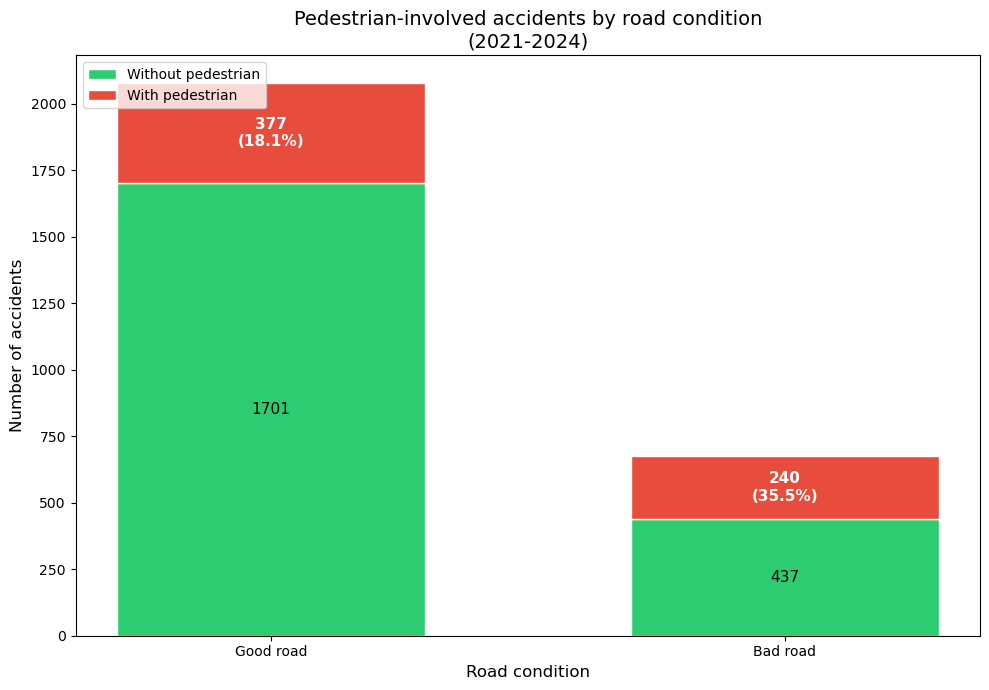

In [19]:
# Data
categories = ['Good road', 'Bad road']
no_pedestrian = [1701, 437]
pedestrian = [377, 240]

# Percentages for labels
total = np.array(no_pedestrian) + np.array(pedestrian)
ped_pct = np.array(pedestrian) / total * 100

fig, ax = plt.subplots(figsize=(10, 7))

# Bars
x = np.arange(len(categories))
width = 0.6

bars1 = ax.bar(x, no_pedestrian, width, label='Without pedestrian', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x, pedestrian, width, bottom=no_pedestrian, label='With pedestrian', color='#e74c3c', edgecolor='white')

# Labels on bars
for i, (p, np) in enumerate(zip(pedestrian, no_pedestrian)):
    ax.text(i, np + p/2, f'{p}\n({ped_pct[i]:.1f}%)', 
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.text(i, np/2, f'{np}', ha='center', va='center', fontsize=11, color='black')

ax.set_xlabel('Road condition', fontsize=12)
ax.set_ylabel('Number of accidents', fontsize=12)
ax.set_title('Pedestrian-involved accidents by road condition\n(2021-2024)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [20]:
#plt.savefig('C:/PythonGIS/geopython2025/mcarto-main/pedestrian_by_road_condition.png', dpi=150, bbox_inches='tight')


## 3. Relationship between pedestrian accidents and weather conditions

Now it needs to repeat the same steps regarding weather conditions.

In [21]:
gdf.head(5)

,id,fatalities,street,ins_street,settl_unit,accs_type,pedestrian,road_type,road_cond,speed_kmh,weather,lighting,date,geometry,is_pedestrian,bad_road,pedestrian_num,bad_road_num
0,1,0,Peterburi tee,Kuuli tn,Lasnamäe linnaosa,Sõidukite külgkokkupõrge,0.0,Tänav,Kuiv,50.0,Selged olud,Valge aeg,2023-04-14,POINT (548805 6588729),False,False,0,0
1,2,0,Reidi tee,Narva mnt,Kesklinna linnaosa,Sõidukite külgkokkupõrge,0.0,Jalg- ja jalgrattatee,Kuiv,50.0,Selged olud,Valge aeg,2022-08-22,POINT (544773 6589755),False,False,0,0
2,3,0,Mustakivi tee,None,Lasnamäe linnaosa,Sõiduki ümberpaiskumine teel,0.0,Tänav,Kuiv,50.0,Selged olud,Valge aeg,2022-06-23,POINT (548925 6589532),False,False,0,0
3,4,0,Järvevana tee,None,Kesklinna linnaosa,Sõiduki ümberpaiskumine teel,0.0,Jalg- ja jalgrattatee,Kuiv,NaN,Pilvised olud,Valge aeg,2023-07-23,POINT (542033 6585478),False,False,0,0
4,5,0,Pikri tn,None,Lasnamäe linnaosa,Kokkupõrge teel oleva takistusega,0.0,Tänav,Pole teada,NaN,Pole teada,Teadmine puudub,2024-05-23,POINT (547834 6589239),False,False,0,0


In [22]:
print("Unique values in 'weather':")
print(pedestrian_accidents['weather'].unique())
print(f"\nAll values: {len(pedestrian_accidents)}")

Unique values in 'weather':
['Lumised olud' 'Selged olud' 'Pilvised olud' 'Vihmasadu' None
 'Pole teada' 'Madal vastu paistev päike']

All values: 617


In [23]:
gdf['is_pedestrian_2'] = (
    (gdf['accs_type'] == 'Kokkupõrge jalakäijaga') | 
    (gdf['pedestrian'] == 1)
)

In [24]:
# Defining "bad weather"
bad_weather = [
    'Lumised olud',      # snow
    'Vihmasadu',         # rain
    'Madal vastu paistev päike'  # low sun (blinding)
]

In [25]:
gdf['bad_weather'] = gdf['weather'].isin(bad_weather)

gdf['pedestrian_num_2'] = gdf['is_pedestrian_2'].astype(int)
gdf['bad_weather_num'] = gdf['bad_weather'].astype(int)

print(f"All accidents: {len(gdf)}")
print(f"With pedestrian: {gdf['is_pedestrian_2'].sum()}")
print(f"Bad weather: {gdf['bad_weather'].sum()}")

All accidents: 2755
With pedestrian: 617
Bad weather: 168


In [26]:
confusion_table = pd.crosstab(
    gdf['is_pedestrian_2'],
    gdf['bad_weather'],
    margins=True,
    margins_name='Total'
)

print("CONTINGENCY TABLE")
print("=" * 50)
print(confusion_table)

confusion_table.columns = ['Good weather', 'Bad weather', 'Total']
confusion_table.index = ['Without pedestrian', 'With pedestrian', 'Total']

print("\nFORMATTED TABLE:")
print(confusion_table)

a = confusion_table.loc['With pedestrian', 'Bad weather']   # pedestrian + bad weather
b = confusion_table.loc['With pedestrian', 'Good weather']  # pedestrian + good weather
c = confusion_table.loc['Without pedestrian', 'Bad weather'] # non-pedestrian + bad weather
d = confusion_table.loc['Without pedestrian', 'Good weather'] # non-pedestrian + good weather

print(f"\nValues:")
print(f"a (pedestrian + bad weather): {a}")
print(f"b (pedestrian + good weather): {b}")
print(f"c (non-pedestrian + bad weather): {c}")
print(f"d (non-pedestrian + good weather): {d}")

CONTINGENCY TABLE
bad_weather      False  True  Total
is_pedestrian_2                    
False             2025   113   2138
True               562    55    617
Total             2587   168   2755

FORMATTED TABLE:
                    Good weather  Bad weather  Total
Without pedestrian          2025          113   2138
With pedestrian              562           55    617
Total                       2587          168   2755

Values:
a (pedestrian + bad weather): 55
b (pedestrian + good weather): 562
c (non-pedestrian + bad weather): 113
d (non-pedestrian + good weather): 2025


In [27]:
import numpy as np

In [28]:
# 1. Odds Ratio
odds_ratio = (a * d) / (b * c) if (b * c) > 0 else float('inf')
log_odds = np.log(odds_ratio)

# 2. Chi-square test
table = [[a, b], [c, d]]
chi2, p, dof, expected = chi2_contingency(table)

# 3. Point-biserial correlation
corr, corr_p = pointbiserialr(gdf['bad_weather_num'], gdf['pedestrian_num_2'])

# 4. Cramér's V
def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    n = sum([sum(row) for row in table])
    phi2 = chi2 / n
    r, k = 2, 2
    return np.sqrt(phi2 / min(k-1, r-1))

v = cramers_v(table)

print("RESULTS")
print(f"Odds Ratio = {odds_ratio:.3f}")
print(f"Log(Odds Ratio) = {log_odds:.3f}")
print(f"Chi-square = {chi2:.4f}, p-value = {p:.6f}")
print(f"Point-biserial correlation r = {corr:.4f}, p = {corr_p:.6f}")
print(f"Cramér's V = {v:.4f}")


RESULTS
Odds Ratio = 1.754
Log(Odds Ratio) = 0.562
Chi-square = 10.3865, p-value = 0.001269
Point-biserial correlation r = 0.0632, p = 0.000900
Cramér's V = 0.0614


**Odds Ratio = 1.75** — Pedestrian accidents are 1.75 times more likely in bad weather than in good weather.

**Chi-square = 10.39, p = 0.0013** — The association is statistically significant (p < 0.05).

**Cramér's V = 0.06** — Indicates a very weak association between bad weather and pedestrian accidents.

**Point-biserial correlation r = 0.06** — Confirms the positive but very weak relationship.

**Conclusions**: Both factors are statistically significant, but road condition has a stronger influence on pedestrian accident risk than weather conditions. Poor road surface (ice, snow, wetness) increases risk 2.5 times, while bad weather increases risk 1.75 times.



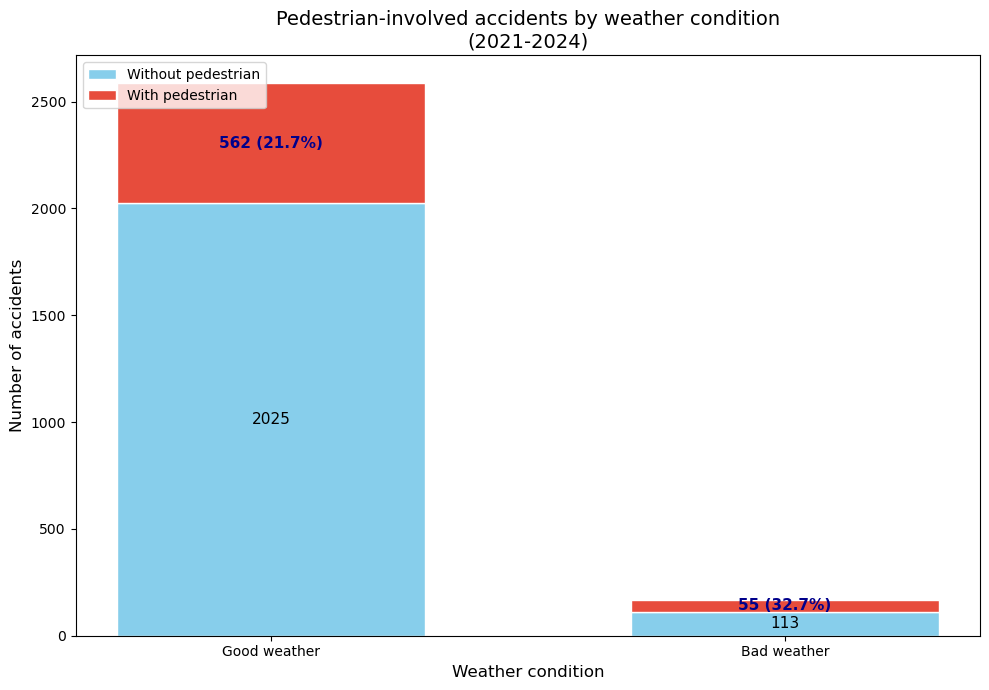

In [29]:
# Calculate percentages for visualization
total_good = b + d
total_bad = a + c
ped_pct_good = b / total_good * 100 if total_good > 0 else 0
ped_pct_bad = a / total_bad * 100 if total_bad > 0 else 0

categories = ['Good weather', 'Bad weather']
no_pedestrian_weather = [d, c]
pedestrian_weather = [b, a]
ped_pct = [ped_pct_good, ped_pct_bad]

fig, ax = plt.subplots(figsize=(10, 7))

x = [0, 1]
width = 0.6

bars1 = ax.bar(x, no_pedestrian_weather, width, label='Without pedestrian', color='#87CEEB', edgecolor='white')
bars2 = ax.bar(x, pedestrian_weather, width, bottom=no_pedestrian_weather, label='With pedestrian', color='#e74c3c', edgecolor='white')

# Labels on bars
for i in range(len(categories)):
    ax.text(i, no_pedestrian_weather[i] + pedestrian_weather[i]/2, 
            f'{pedestrian_weather[i]} ({ped_pct[i]:.1f}%)', 
            ha='center', va='center', fontsize=11, fontweight='bold', color='darkblue')
    ax.text(i, no_pedestrian_weather[i]/2, f'{no_pedestrian_weather[i]}', 
            ha='center', va='center', fontsize=11, color='black')

ax.set_xlabel('Weather condition', fontsize=12)
ax.set_ylabel('Number of accidents', fontsize=12)
ax.set_title('Pedestrian-involved accidents by weather condition\n(2021-2024)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [30]:
#plt.savefig('C:/PythonGIS/geopython2025/mcarto-main/pedestrian_by_weather.png', dpi=150, bbox_inches='tight')


Detailed analysis by road condition:
                         road_cond  total  pedestrian        pct
3               Kohev lahtine lumi     26          15  57.692308
4                     Pori, saaste     23          12  52.173913
5  Töödeldud pinnaga jäätunud kate     10           5  50.000000
2      Lumelörts, soolalumine segu     71          24  33.802817
1                             Märg    535         178  33.271028
0                             Kuiv   1793         327  18.237591


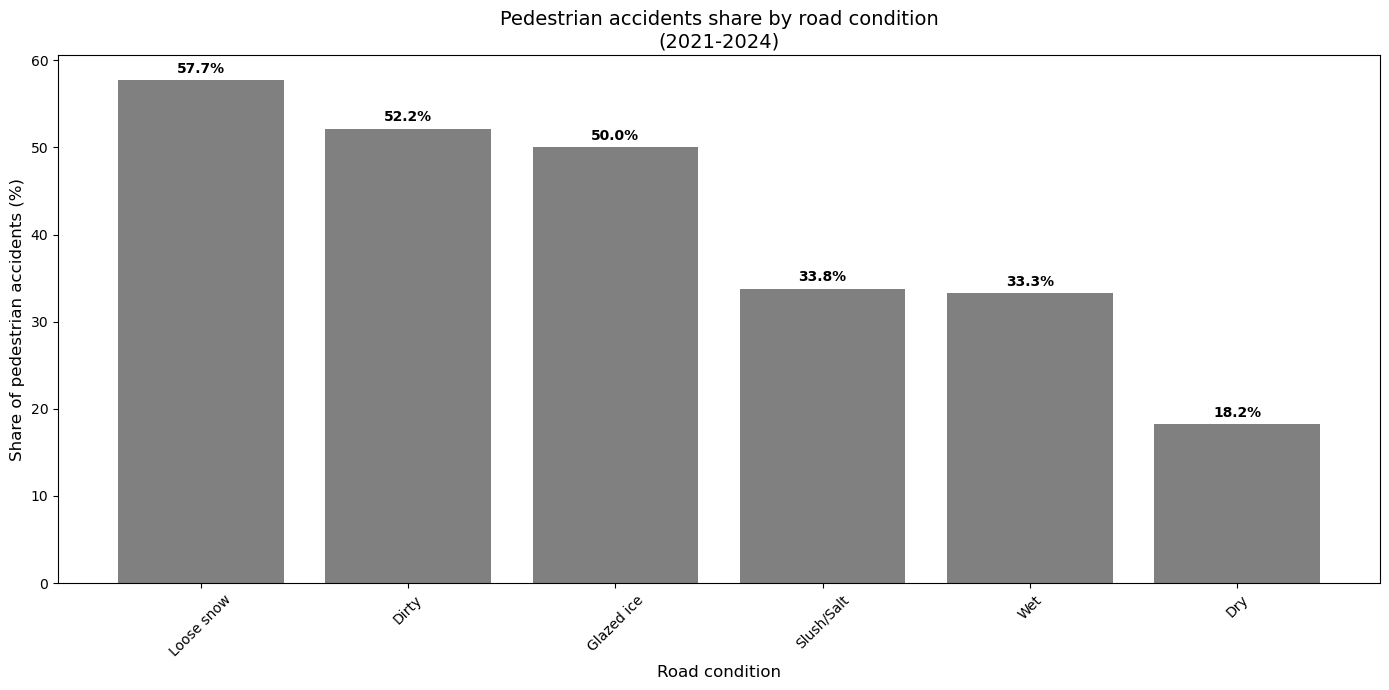

In [41]:
# Detailed analysis by road condition
road_conditions = ['Kuiv', 'Märg', 'Lumelörts, soolalumine segu', 'Kohev lahtine lumi', 
                   'Pori, saaste', 'Töödeldud pinnaga jäätunud kate']

results_road = []
for condition in road_conditions:
    total = len(gdf[gdf['road_cond'] == condition])
    pedestrian_count = len(gdf[(gdf['road_cond'] == condition) & (gdf['is_pedestrian'])])
    pct = pedestrian_count / total * 100 if total > 0 else 0
    results_road.append({'road_cond': condition, 'total': total, 'pedestrian': pedestrian_count, 'pct': pct})

df_results_road = pd.DataFrame(results_road).sort_values('pct', ascending=False)

print("\nDetailed analysis by road condition:")
print(df_results_road)

# Bar chart for road conditions
fig, ax = plt.subplots(figsize=(14, 7))

road_labels = {
    'Kuiv': 'Dry',
    'Märg': 'Wet',
    'Lumelörts, soolalumine segu': 'Slush/Salt',
    'Kohev lahtine lumi': 'Loose snow',
    'Pori, saaste': 'Dirty',
    'Töödeldud pinnaga jäätunud kate': 'Glazed ice',
}

df_results_road['road_cond_en'] = df_results_road['road_cond'].map(road_labels)

bars = ax.bar(df_results_road['road_cond_en'], df_results_road['pct'], color='grey')
ax.set_xlabel('Road condition', fontsize=12)
ax.set_ylabel('Share of pedestrian accidents (%)', fontsize=12)
ax.set_title('Pedestrian accidents share by road condition\n(2021-2024)', fontsize=14)
ax.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, pct in zip(bars, df_results_road['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [43]:
#plt.savefig('C:/PythonGIS/geopython2025/mcarto-main/pedestrian_by_roadcond_detail.png', dpi=150, bbox_inches='tight')

Loose snow, dirt, and ice create the most dangerous environments for pedestrians — accident probability increased by 2.5–3 times compared to dry conditions.


Detailed analysis by weather type:
                     weather  total  pedestrian        pct
2               Lumised olud     52          21  40.384615
4  Madal vastu paistev päike     18           7  38.888889
1              Pilvised olud   1071         311  29.038282
3                  Vihmasadu     98          27  27.551020
0                Selged olud   1232         210  17.045455


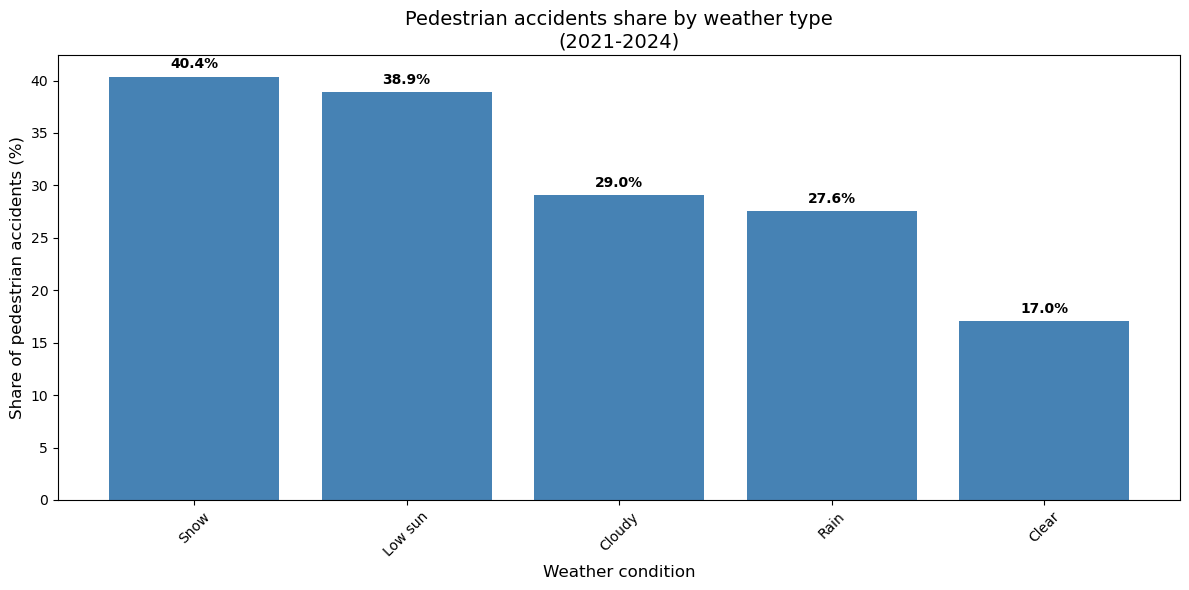

In [44]:
# Detailed analysis by weather type
weather_types = ['Selged olud', 'Pilvised olud', 'Lumised olud', 'Vihmasadu', 'Madal vastu paistev päike']

results = []
for weather in weather_types:
    total = len(gdf[gdf['weather'] == weather])
    pedestrian_count = len(gdf[(gdf['weather'] == weather) & (gdf['is_pedestrian'])])
    pct = pedestrian_count / total * 100 if total > 0 else 0
    results.append({'weather': weather, 'total': total, 'pedestrian': pedestrian_count, 'pct': pct})

df_results = pd.DataFrame(results).sort_values('pct', ascending=False)

print("\nDetailed analysis by weather type:")
print(df_results)

# Bar chart for weather types
fig, ax = plt.subplots(figsize=(12, 6))

weather_labels = {
    'Selged olud': 'Clear',
    'Pilvised olud': 'Cloudy',
    'Lumised olud': 'Snow',
    'Vihmasadu': 'Rain',
    'Madal vastu paistev päike': 'Low sun'
}

df_results['weather_en'] = df_results['weather'].map(weather_labels)

bars = ax.bar(df_results['weather_en'], df_results['pct'], color='steelblue')
ax.set_xlabel('Weather condition', fontsize=12)
ax.set_ylabel('Share of pedestrian accidents (%)', fontsize=12)
ax.set_title('Pedestrian accidents share by weather type\n(2021-2024)', fontsize=14)
ax.tick_params(axis='x', rotation=45)  # Changed: removed 'ha' parameter

# Add value labels on bars
for bar, pct in zip(bars, df_results['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

As we can see, weather conditions influence the percentage of accidents involving pedestrians, which is especially important to consider, as in Estonia, especially on the coast, where Tallinn is located, weather conditions are often less than ideal.

In [45]:
#plt.savefig('C:/PythonGIS/geopython2025/mcarto-main/pedestrian_by_weather_detail.png', dpi=150, bbox_inches='tight')